<a href="https://colab.research.google.com/github/kosar-am/rice-classification-cnn/blob/main/rice_classification_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rice Variety Classification Using CNN

This project uses a Convolutional Neural Network (CNN) to classify rice images into five different varieties:

- Arborio
- Basmati
- Ipsala
- Jasmine
- Karacadag

In [15]:
# Install required packages

!pip install -q kagglehub

In [32]:
# Import standard libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import hashlib

from PIL import Image








In [17]:
# Import KaggleHub

import kagglehub

In [18]:
# Download the rice dataset from Kaggle

dataset_path = kagglehub.dataset_download(
    "muratkokludataset/rice-image-dataset"
)

print("Dataset downloaded successfully.")
print(dataset_path)

Using Colab cache for faster access to the 'rice-image-dataset' dataset.
Dataset downloaded successfully.
/kaggle/input/rice-image-dataset


# Explore Dataset Structure

In [19]:
# Display the dataset location

print(dataset_path)

/kaggle/input/rice-image-dataset


In [20]:
# List all files and folders in the downloaded dataset

print(os.listdir(dataset_path))

['Rice_Image_Dataset']


In [21]:
# Enter the main dataset folder

rice_dataset_path = os.path.join(dataset_path, "Rice_Image_Dataset")

print(rice_dataset_path)

/kaggle/input/rice-image-dataset/Rice_Image_Dataset


In [22]:
# List all files and folders inside the Rice_Image_Dataset folder

print(os.listdir(rice_dataset_path))

['Karacadag', 'Basmati', 'Jasmine', 'Rice_Citation_Request.txt', 'Arborio', 'Ipsala']


# Identify Rice Classes

In [23]:
# Keep only rice class folders

classes = [
    item
    for item in os.listdir(rice_dataset_path)
    if os.path.isdir(os.path.join(rice_dataset_path, item))
]

print(classes)

['Karacadag', 'Basmati', 'Jasmine', 'Arborio', 'Ipsala']


# Inspect Dataset

In [24]:
# Count the number of images in each rice class

image_counts = {}

for class_name in classes:
    class_path = os.path.join(rice_dataset_path, class_name)

    image_files = [
        file_name
        for file_name in os.listdir(class_path)
        if file_name.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_counts[class_name] = len(image_files)

print(image_counts)

{'Karacadag': 15000, 'Basmati': 15000, 'Jasmine': 15000, 'Arborio': 15000, 'Ipsala': 15000}


## Check Image Size

In [25]:
# Check the size of one sample image from each rice class

for class_name in classes:
    class_path = os.path.join(rice_dataset_path, class_name)

    image_files = [
        file_name
        for file_name in os.listdir(class_path)
        if file_name.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    sample_image_path = os.path.join(class_path, image_files[0])

    with Image.open(sample_image_path) as image:
        print(f"{class_name}: {image.size}")

Karacadag: (250, 250)
Basmati: (250, 250)
Jasmine: (250, 250)
Arborio: (250, 250)
Ipsala: (250, 250)


In [26]:
# Check the size of every image in the dataset

image_sizes = set()

for class_name in classes:
    class_path = os.path.join(rice_dataset_path, class_name)

    image_files = [
        file_name
        for file_name in os.listdir(class_path)
        if file_name.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    for file_name in image_files:
        image_path = os.path.join(class_path, file_name)

        with Image.open(image_path) as image:
            image_sizes.add(image.size)

print("Unique image sizes:", image_sizes)
print("Number of unique sizes:", len(image_sizes))

Unique image sizes: {(250, 250)}
Number of unique sizes: 1


## Check Image Color Modes

In [27]:
# Check the color mode of every image in the dataset

image_modes = set()

for class_name in classes:
    class_path = os.path.join(rice_dataset_path, class_name)

    image_files = [
        file_name
        for file_name in os.listdir(class_path)
        if file_name.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    for file_name in image_files:
        image_path = os.path.join(class_path, file_name)

        with Image.open(image_path) as image:
            image_modes.add(image.mode)

print("Unique image modes:", image_modes)
print("Number of unique modes:", len(image_modes))

Unique image modes: {'RGB'}
Number of unique modes: 1


## Check Corrupted Images

In [28]:
# Check for corrupted images in the dataset

corrupted_images = []

for class_name in classes:

    class_path = os.path.join(rice_dataset_path, class_name)

    image_files = [
        file_name
        for file_name in os.listdir(class_path)
        if file_name.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    for file_name in image_files:

        image_path = os.path.join(class_path, file_name)

        try:
            with Image.open(image_path) as image:
                image.verify()

        except Exception:
            corrupted_images.append(image_path)

print("Number of corrupted images:", len(corrupted_images))

Number of corrupted images: 0


## Check Duplicate Images

In [29]:
# Check for exact duplicate images using file hashes



image_hashes = {}
duplicate_images = []

for class_name in classes:
    class_path = os.path.join(rice_dataset_path, class_name)

    image_files = [
        file_name
        for file_name in os.listdir(class_path)
        if file_name.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    for file_name in image_files:
        image_path = os.path.join(class_path, file_name)

        with open(image_path, "rb") as file:
            file_hash = hashlib.md5(file.read()).hexdigest()

        if file_hash in image_hashes:
            duplicate_images.append(
                (image_hashes[file_hash], image_path)
            )
        else:
            image_hashes[file_hash] = image_path

print("Number of duplicate images:", len(duplicate_images))

Number of duplicate images: 297


In [30]:
# Display the first five duplicate pairs

for original, duplicate in duplicate_images[:5]:
    print("Original:", original)
    print("Duplicate:", duplicate)
    print("-" * 50)

Original: /kaggle/input/rice-image-dataset/Rice_Image_Dataset/Ipsala/Ipsala (2554).jpg
Duplicate: /kaggle/input/rice-image-dataset/Rice_Image_Dataset/Ipsala/Ipsala (2419).jpg
--------------------------------------------------
Original: /kaggle/input/rice-image-dataset/Rice_Image_Dataset/Ipsala/Ipsala (2305).jpg
Duplicate: /kaggle/input/rice-image-dataset/Rice_Image_Dataset/Ipsala/Ipsala (2433).jpg
--------------------------------------------------
Original: /kaggle/input/rice-image-dataset/Rice_Image_Dataset/Ipsala/Ipsala (2260).jpg
Duplicate: /kaggle/input/rice-image-dataset/Rice_Image_Dataset/Ipsala/Ipsala (2146).jpg
--------------------------------------------------
Original: /kaggle/input/rice-image-dataset/Rice_Image_Dataset/Ipsala/Ipsala (2562).jpg
Duplicate: /kaggle/input/rice-image-dataset/Rice_Image_Dataset/Ipsala/Ipsala (2428).jpg
--------------------------------------------------
Original: /kaggle/input/rice-image-dataset/Rice_Image_Dataset/Ipsala/Ipsala (2552).jpg
Duplicate

## Check Duplicate Images Across Different Classes

In [34]:
# Check whether duplicate images belong to different classes

cross_class_duplicates = []

for original, duplicate in duplicate_images:
    original_class = os.path.basename(os.path.dirname(original))
    duplicate_class = os.path.basename(os.path.dirname(duplicate))

    if original_class != duplicate_class:
        cross_class_duplicates.append((original, duplicate))

print("Cross-class duplicate images:", len(cross_class_duplicates))

Cross-class duplicate images: 0


## Display Sample Images

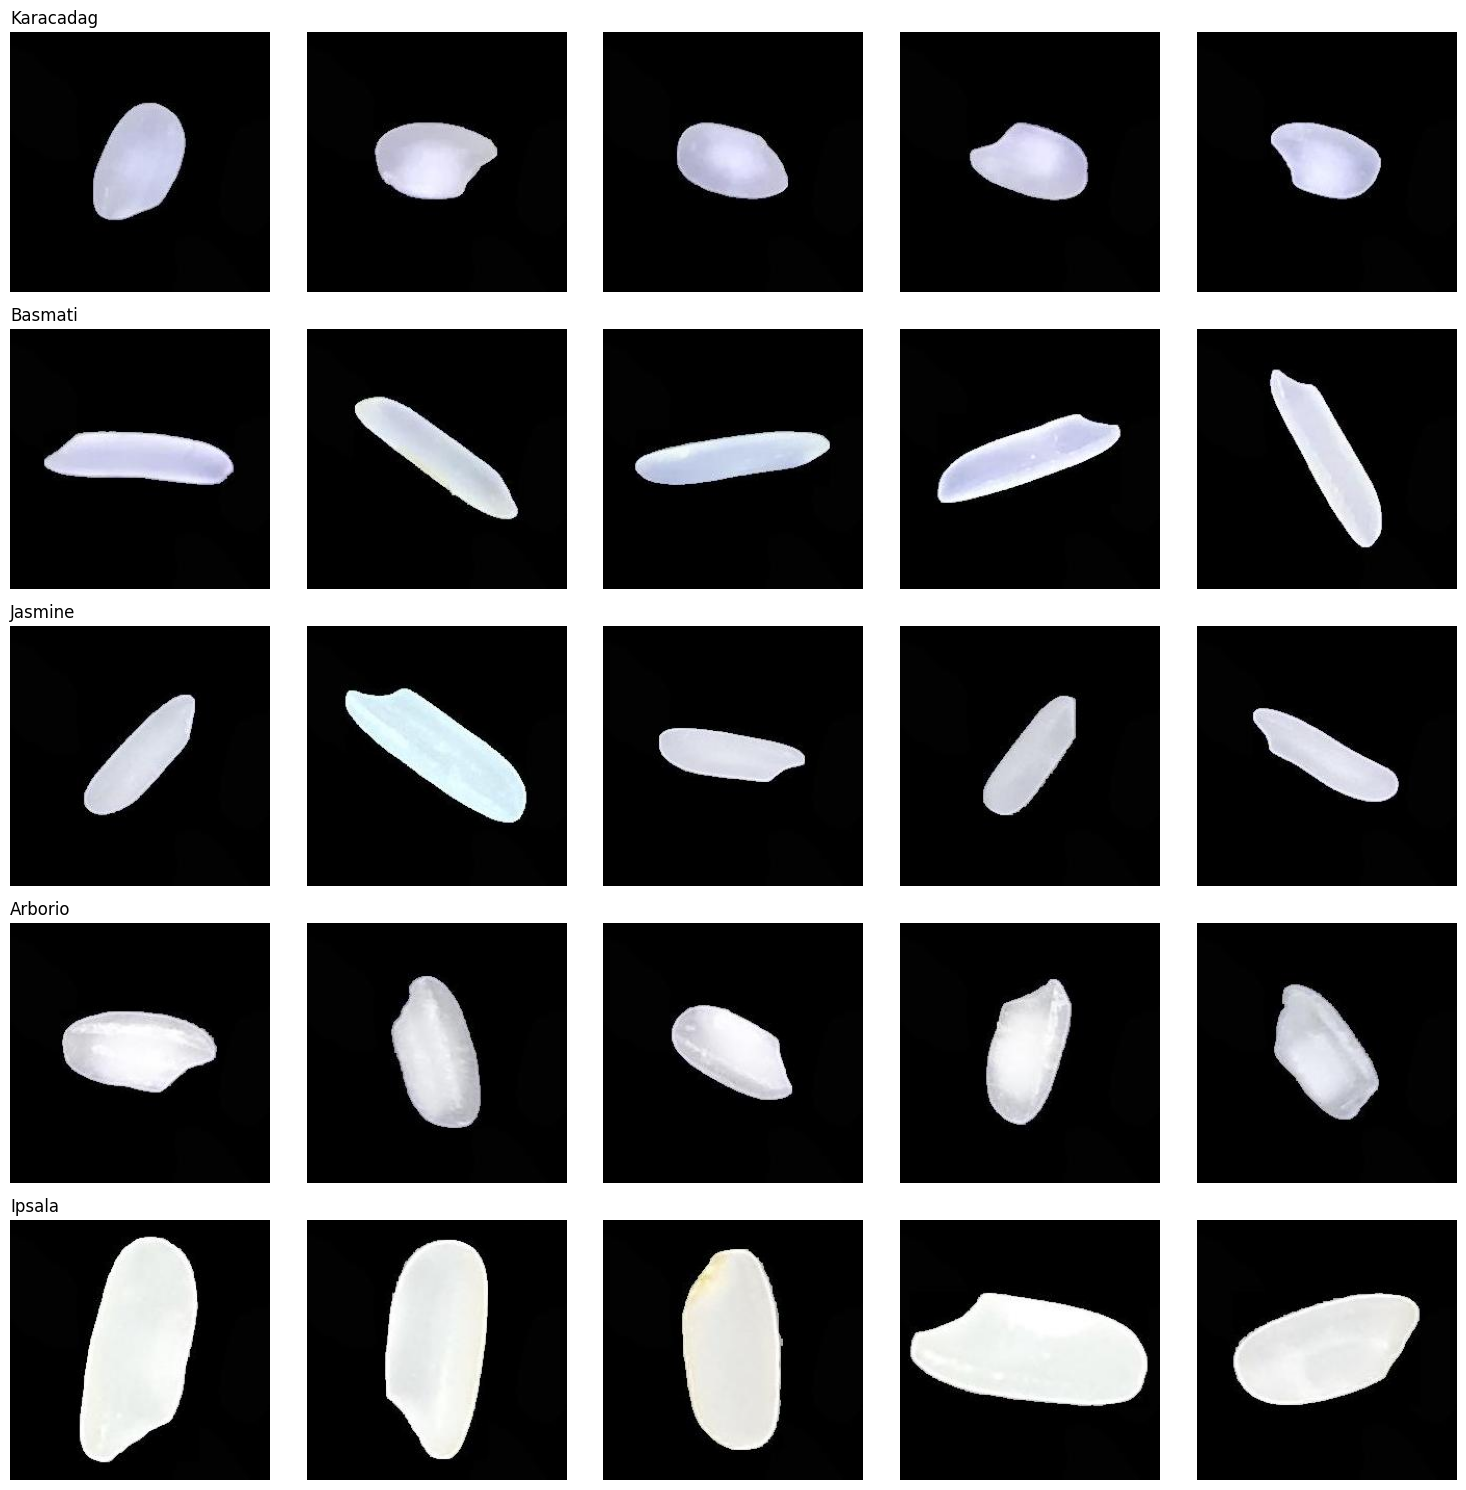

In [38]:
# Display 5 random images from each rice class

num_samples = 5

fig, axes = plt.subplots(len(classes), num_samples, figsize=(15, 15))

for row, class_name in enumerate(classes):

    class_path = os.path.join(rice_dataset_path, class_name)

    image_files = [
        file_name
        for file_name in os.listdir(class_path)
        if file_name.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    random_images = random.sample(image_files, num_samples)

    for col, image_name in enumerate(random_images):

        image_path = os.path.join(class_path, image_name)

        image = Image.open(image_path)

        axes[row, col].imshow(image)
        axes[row, col].axis("off")

        if col == 0:
          axes[row, col].set_title(class_name, fontsize=12, loc="left")


plt.tight_layout()
plt.show()